Weather rows: 8760 from 2025-01-01 00:00:00 to 2025-12-31 23:00:00
✅ CSV saved to: C:\Users\User\Downloads\load_profiles_energy_balance.csv


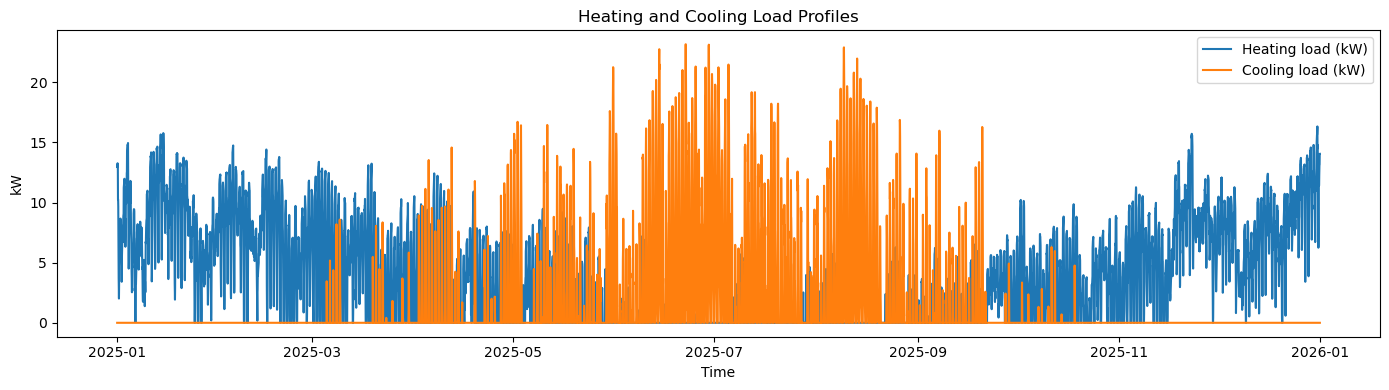

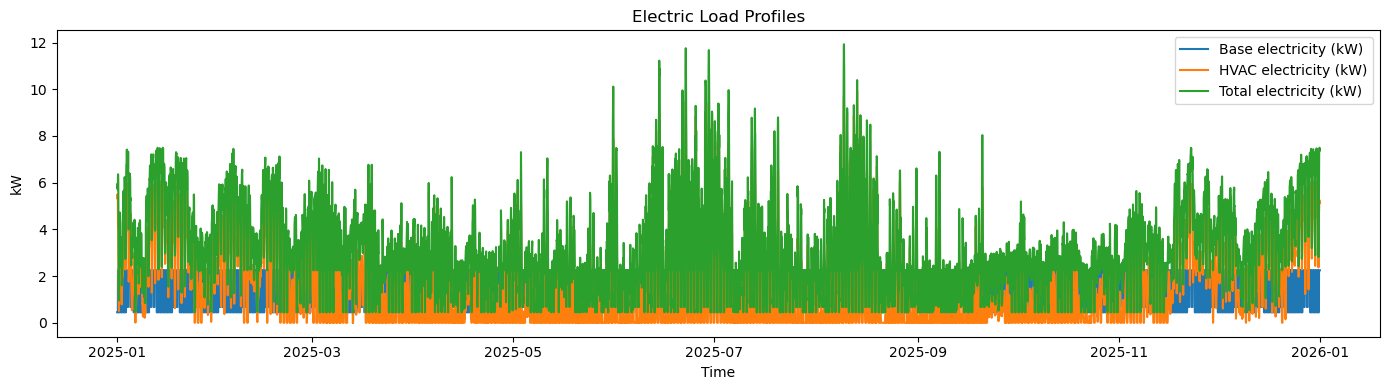

In [9]:
# ============================================================
# BUILDING LOAD PROFILES GENERATION (PYTHON)
# Model type: Physics-based (first-principles) simplified ENERGY BALANCE model
# Goal: generate hourly HeatingLoad(t), CoolingLoad(t), ElectricLoad(t)
#
# INPUTS:
#  - Weather: Tout(t) [°C], global shortwave radiation G(t) [W/m²]
#  - Building data: from your selected paper table (U-values, WWR, SHGC, Volume, ACH, occupants, LPD)
#  - Setpoints: heating/cooling indoor setpoints
#
# CORE PHYSICS (from HVAC course fundamentals):
#  - Heat transfer: conduction+convection aggregated via U-value -> UAΔT (overall conductance)
#  - Infiltration/ventilation losses: m_dot * cp * ΔT using ACH
#  - Solar gains through windows: Q_solar = G * A_window * SHGC (simplified)
#
# NOTE ON TERMINOLOGY:
#  - This is NOT a full white-box simulator (EnergyPlus).
#  - It is a first-principles energy balance model (forward/physics-based) suitable for Python.
# ============================================================

import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# 0) FILE PATH (Windows)
# -----------------------------
# Hypothesis: You exported hourly weather to a CSV (meteoblue-style export).
#WEATHER_CSV = r"C:\Users\User\Downloads\dataexport_20260228T140237.csv"
WEATHER_CSV = Path("dataexport_20260228T140237.csv")

if not os.path.exists(WEATHER_CSV):
    raise FileNotFoundError(
        f"File not found: {WEATHER_CSV}\n"
        "Fix: put the correct path OR put the csv in the same folder as your script."
    )

OUT_DIR = Path(WEATHER_CSV).parent
OUT_CSV = OUT_DIR / "load_profiles_energy_balance.csv"


# ============================================================
# 1) READ WEATHER DATA (meteoblue-style export)
# ============================================================
# Hypothesis: the CSV contains ~9 metadata rows then hourly series.
dfw = pd.read_csv(WEATHER_CSV)

META_ROWS = 9
raw = dfw.iloc[META_ROWS:].copy()

# The export usually has 1st column = timestamp, then variables.
col_temp  = dfw.columns[1]  # Temperature [2 m elevation corrected]
col_wind  = dfw.columns[2]  # Wind Speed [10 m] (not used here)
col_wdir  = dfw.columns[3]  # Wind Direction [10 m] (not used here)
col_solar = dfw.columns[4]  # Shortwave Radiation (global)

raw = raw.rename(columns={
    "location": "timestamp",
    col_temp:  "Tout_C",       # outdoor temperature
    col_solar: "G_Wm2"         # global shortwave radiation
})

raw["timestamp"] = pd.to_datetime(raw["timestamp"], format="%Y%m%dT%H%M")
raw["Tout_C"] = pd.to_numeric(raw["Tout_C"], errors="coerce")
raw["G_Wm2"]  = pd.to_numeric(raw["G_Wm2"],  errors="coerce")

weather = raw.set_index("timestamp").sort_index()

Tout = weather["Tout_C"].values
G    = weather["G_Wm2"].values

# Basic check (should be ~8760 for a full year hourly)
print("Weather rows:", len(weather), "from", weather.index.min(), "to", weather.index.max())


# ============================================================
# 2) BUILDING DATA (FROM YOUR ARTICLE TABLE)
# ============================================================
# Source: your chosen building paper (Table A.1): U-values, SHGC, WWR, volume, ACH, occupants, lighting density
A_total = 259.0         # m²
A_cond  = 173.0         # m² conditioned area
V_build = 873.0         # m³
floors  = 3

WWR      = 0.19         # window-wall ratio [-]
U_wall   = 0.4          # W/m²K
U_roof   = 0.3          # W/m²K
U_ground = 0.3          # W/m²K
U_window = 1.2          # W/m²K
SHGC     = 0.6          # [-]
ACH      = 1.58         # 1/h
n_occ    = 4

# ============================================================
# 3) GEOMETRY RECONSTRUCTION (ASSUMPTION)
# ============================================================
# We do NOT have the real plans; we adopt a standard "box model" approximation.
# Hypotheses:
#  - footprint area ≈ A_cond / floors
#  - square footprint
#  - floor-to-floor height = 2.8 m (typical)
A_foot = A_cond / floors
side = np.sqrt(A_foot)
perim = 4 * side
h_floor = 2.8
height = floors * h_floor

A_wall_gross = perim * height
A_window = WWR * A_wall_gross
A_wall_opaque = A_wall_gross - A_window
A_roof = A_foot
A_ground = A_foot

# ============================================================
# 4) HEAT LOSS COEFFICIENTS (FROM HVAC COURSE FORMULAS)
# ============================================================
# (i) Transmission (Heat Transfer chapter):
#   H_trans = UA, where UA = Σ(U_i * A_i)  [W/K]
UA = (U_wall * A_wall_opaque +
      U_window * A_window +
      U_roof * A_roof +
      U_ground * A_ground)

# (ii) Infiltration (Ventilation / Heating load basics):
#   m_dot = rho * ACH * V / 3600
#   H_inf = m_dot * cp  [W/K]
rho_air = 1.2      # kg/m³ (assumption)
cp_air  = 1006.0   # J/kgK (assumption)
H_inf = rho_air * cp_air * ACH * V_build / 3600.0

H_total = UA + H_inf  # total heat loss coefficient [W/K]

# ============================================================
# 5) THERMAL CAPACITANCE (ASSUMPTION)
# ============================================================
# A fully detailed model needs material layers.
# Here we approximate an "effective" capacitance:
#   C_air = rho*cp*V
#   C = factor * C_air
# Hypothesis: factor=15 (typical range 10–20 for effective building inertia)
C_air = rho_air * cp_air * V_build
effective_mass_factor = 15.0
C = effective_mass_factor * C_air

# ============================================================
# 6) SETPOINTS (ASSUMPTION / DESIGN CHOICE)
# ============================================================
# Hypotheses:
T_heat_sp = 20.0  # °C
T_cool_sp = 25.0  # °C

# ============================================================
# 7) INTERNAL GAINS (FROM ARTICLE + STANDARD ASSUMPTIONS)
# ============================================================
# People sensible heat: typical 75 W/person (assumption)
Q_people_full = 75.0 * n_occ

# Lighting Power Density from article: 8–10 W/m² -> choose 9 W/m² (assumption within range)
LPD = 9.0  # W/m²
# Equipment Power Density: not given -> choose 4 W/m² (assumption)
EPD = 4.0  # W/m²

# Simple occupancy schedule (assumption):
def occupancy_fraction(ts: pd.Timestamp) -> float:
    h = ts.hour
    dow = ts.dayofweek
    if dow < 5:  # weekdays
        return 1.0 if (6 <= h <= 9 or 17 <= h <= 23) else 0.2
    else:        # weekends
        return 1.0 if (8 <= h <= 23) else 0.3

occ = weather.index.to_series().apply(occupancy_fraction).values

Q_lights = LPD * A_cond * occ
Q_equip  = EPD * A_cond * occ
Q_int    = Q_people_full * occ + Q_lights + Q_equip

# Base electric (non-HVAC): lights + equipment
P_base_elec = Q_lights + Q_equip

# ============================================================
# 8) SOLAR GAINS (FROM HVAC SOLAR CHAPTER, SIMPLIFIED)
# ============================================================
# Ideal: split into direct/diffuse, orientation, shading.
# Here: simplified average:
#   Q_solar = G * A_window * SHGC * f_orient
# Hypothesis: f_orient = 0.6 (average orientation/tilt factor)
f_orient = 0.6
Q_solar = G * A_window * SHGC * f_orient

# ============================================================
# 9) DYNAMIC ENERGY BALANCE SIMULATION (HOURLY)
# ============================================================
# Energy balance:
#   C dTin/dt = H_total*(Tout - Tin) + Q_solar + Q_int + Q_HVAC
# We compute Q_HVAC such that Tin stays within setpoints.
dt = 3600.0
N = len(weather)

Tin    = np.zeros(N)
Q_hvac = np.zeros(N)
Q_heat = np.zeros(N)
Q_cool = np.zeros(N)

Tin[0] = T_heat_sp

for k in range(N - 1):
    # Free-floating (no HVAC)
    Tin_free = Tin[k] + (dt / C) * (H_total*(Tout[k] - Tin[k]) + Q_solar[k] + Q_int[k])

    # If outside comfort band, compute HVAC power needed to hit setpoint at next step
    if Tin_free < T_heat_sp:
        # Solve for Q_HVAC to reach T_heat_sp
        Q_needed = ((T_heat_sp - Tin[k]) * C / dt) - (H_total*(Tout[k] - Tin[k]) + Q_solar[k] + Q_int[k])
        Q_hvac[k] = max(Q_needed, 0.0)
    elif Tin_free > T_cool_sp:
        Q_needed = ((T_cool_sp - Tin[k]) * C / dt) - (H_total*(Tout[k] - Tin[k]) + Q_solar[k] + Q_int[k])
        Q_hvac[k] = min(Q_needed, 0.0)  # negative cooling
    else:
        Q_hvac[k] = 0.0

    Q_heat[k] = max(Q_hvac[k], 0.0)
    Q_cool[k] = max(-Q_hvac[k], 0.0)

    # Update Tin with HVAC applied
    Tin[k+1] = Tin[k] + (dt / C) * (H_total*(Tout[k] - Tin[k]) + Q_solar[k] + Q_int[k] + Q_hvac[k])

Q_heat[-1] = Q_heat[-2]
Q_cool[-1] = Q_cool[-2]

# ============================================================
# 10) HEAT PUMP ELECTRICITY (FROM YOUR COP/EER CURVES PAPER)
# ============================================================
# If you want electric load including HVAC:
#   P_hvac = Q_heat/COP(Tout) + Q_cool/EER(Tout)
#
# Note: COP/EER expressions come from your selected heat pump regression tables.
# Here we use: heating Tw=35°C (low temp), cooling Tw=6°C.
def cop_35(T):
    T = np.asarray(T, dtype=float)
    COP_A = (5e-10*T**6 + 7e-6*T**5 + 2e-5*T**4 - 0.0017*T**3 + 0.0097*T**2 + 0.0787*T + 2.5019)
    COP_B = (-2e-7*T**6 + 2e-5*T**5 - 0.0004*T**4 + 0.0066*T**3 - 0.0606*T**2 + 0.4206*T + 2.0482)
    COP = np.where(T <= 3.0, COP_A, COP_B)  # piecewise as in table
    return np.clip(COP, 1.0, 6.5)

def eer_6(T):
    T = np.asarray(T, dtype=float)
    EER = (-4e-5*T**3 + 0.005*T**2 - 0.2806*T + 7.7483)
    return np.clip(EER, 1.0, 8.0)

COP_t = cop_35(Tout)
EER_t = eer_6(Tout)






P_hvac_elec  = (Q_heat / COP_t) + (Q_cool / EER_t)
P_total_elec = P_base_elec + P_hvac_elec

# ============================================================
# 11) SAVE CSV
# ============================================================
out = pd.DataFrame(index=weather.index)
out["Tout_C"] = Tout
out["Tin_C"]  = Tin
out["SolarGain_W"]    = Q_solar
out["InternalGain_W"] = Q_int

out["HeatingLoad_W"] = Q_heat
out["CoolingLoad_W"] = Q_cool

out["BaseElectric_W"] = P_base_elec
out["HVACElectric_W"] = P_hvac_elec
out["TotalElectric_W"] = P_total_elec

out["COP"] = COP_t
out["EER"] = EER_t

# convenient kW columns
for c in ["HeatingLoad_W","CoolingLoad_W","BaseElectric_W","HVACElectric_W","TotalElectric_W"]:
    out[c.replace("_W","_kW")] = out[c] / 1000.0

out.to_csv(OUT_CSV, index_label="timestamp")
print("✅ CSV saved to:", OUT_CSV)

# ============================================================
# 12) PLOTS (SHOW ON SCREEN + OPTIONAL SAVE)
# ============================================================
# Heating/Cooling plot
plt.figure(figsize=(14,4))
plt.plot(out.index, out["HeatingLoad_kW"], label="Heating load (kW)")
plt.plot(out.index, out["CoolingLoad_kW"], label="Cooling load (kW)")
plt.xlabel("Time")
plt.ylabel("kW")
plt.title("Heating and Cooling Load Profiles")
plt.legend()
plt.tight_layout()
plt.show()   # ✅ show in your Python/Jupyter environment

# Electricity plot
plt.figure(figsize=(14,4))
plt.plot(out.index, out["BaseElectric_kW"], label="Base electricity (kW)")
plt.plot(out.index, out["HVACElectric_kW"], label="HVAC electricity (kW)")
plt.plot(out.index, out["TotalElectric_kW"], label="Total electricity (kW)")
plt.xlabel("Time")
plt.ylabel("kW")
plt.title("Electric Load Profiles")
plt.legend()
plt.tight_layout()
plt.show()   # ✅ show in your Python/Jupyter environment

# Optional: save plots too
# (uncomment if you want files)
# out_plot_dir = OUT_DIR
# plt.figure(figsize=(14,4))
# plt.plot(out.index, out["HeatingLoad_kW"], label="Heating load (kW)")
# plt.plot(out.index, out["CoolingLoad_kW"], label="Cooling load (kW)")
# plt.legend(); plt.tight_layout()
# plt.savefig(out_plot_dir/"profile_heating_cooling.png", dpi=150); plt.close()
#
# plt.figure(figsize=(14,4))
# plt.plot(out.index, out["TotalElectric_kW"], label="Total electricity (kW)")
# plt.legend(); plt.tight_layout()
# plt.savefig(out_plot_dir/"profile_electricity.png", dpi=150); plt.close()

In [10]:
# --- COP/EER for CALCULATIONS (no NaN) ---
COP_calc = cop_35(Tout)
EER_calc = eer_6(Tout)

# Electricity for HVAC (robust: only compute when load > 0)
P_hvac_elec = np.zeros_like(Q_heat, dtype=float)
P_hvac_elec += np.where(Q_heat > 0, Q_heat / COP_calc, 0.0)
P_hvac_elec += np.where(Q_cool > 0, Q_cool / EER_calc, 0.0)

P_total_elec = P_base_elec + P_hvac_elec

# --- COP/EER for PLOTTING only (masked) ---
COP_plot = COP_calc.copy()
EER_plot = EER_calc.copy()
COP_plot[Q_heat == 0] = np.nan
EER_plot[Q_cool == 0] = np.nan

# (si tu veux garder les colonnes)
out["COP"] = COP_plot
out["EER"] = EER_plot
out["HVACElectric_W"] = P_hvac_elec
out["TotalElectric_W"] = P_total_elec
out["HVACElectric_kW"] = out["HVACElectric_W"]/1000
out["TotalElectric_kW"] = out["TotalElectric_W"]/1000

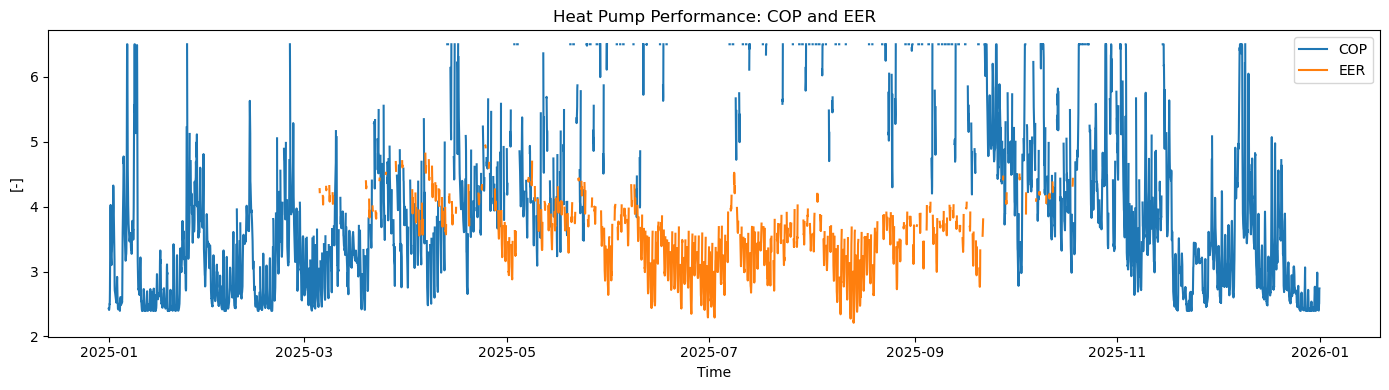

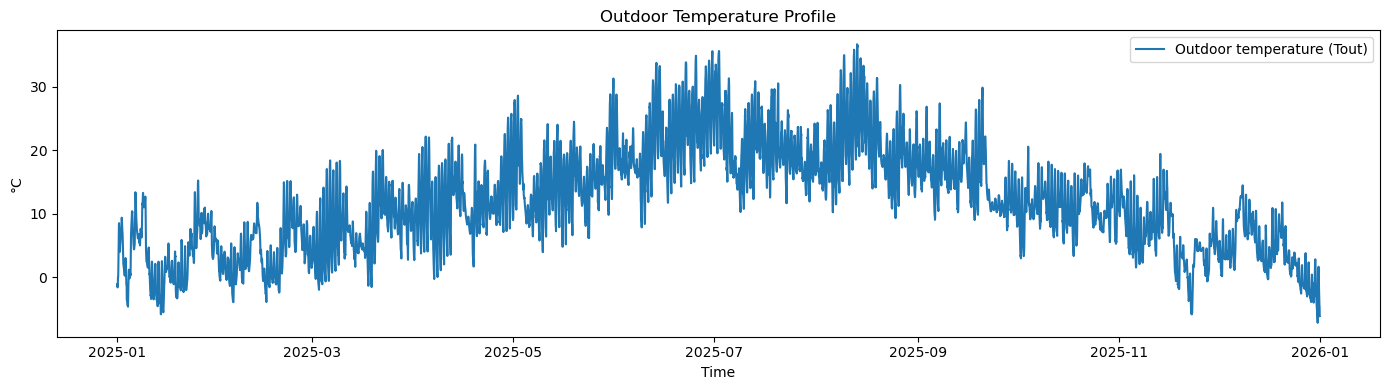

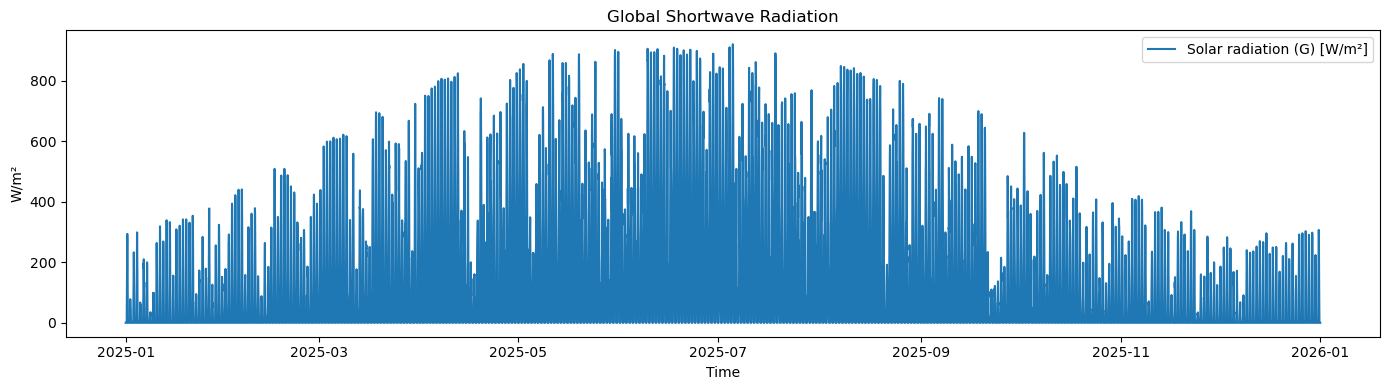

ℹ️ Wind speed not found in 'weather'. If you want it, keep wind_kmh column when parsing.


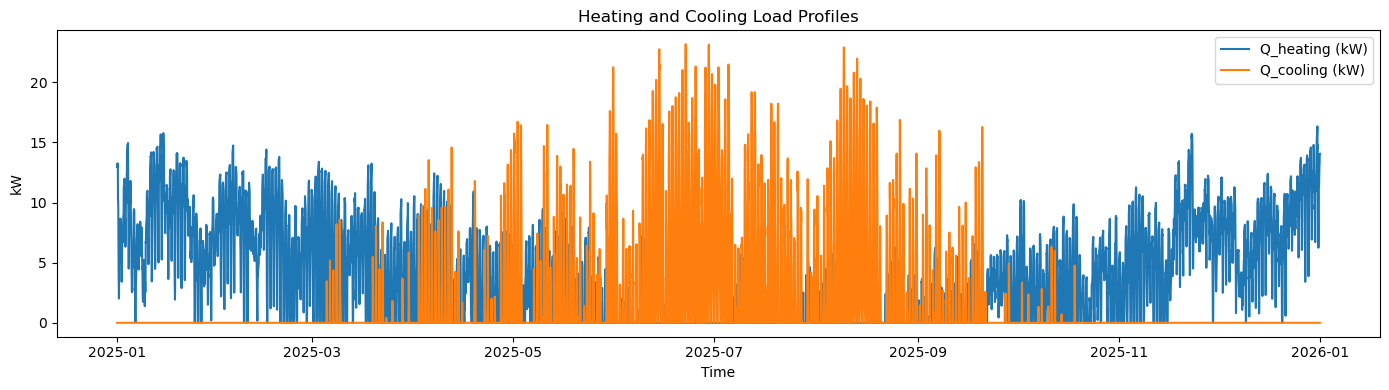

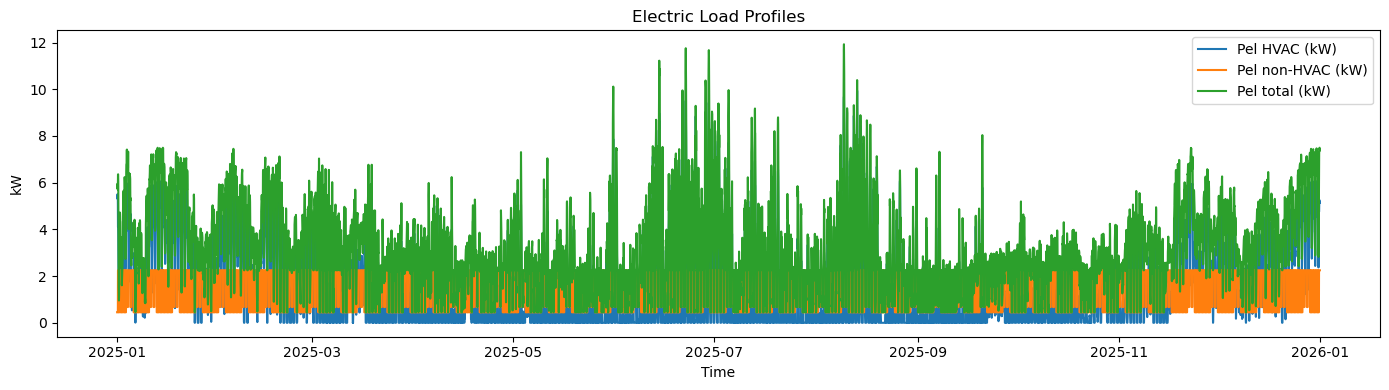

In [11]:
# ============================================================
# PLOTS ONLY (from the outputs already computed in your script)
# Plots:
#  - COP & EER
#  - Outdoor temperature
#  - Solar radiation
#  - Wind speed (if available)
#  - Qheating, Qcooling
#  - Pel_HVAC, Pel_nonHVAC, Pel_total
#
# ASSUMPTION:
#  - You already ran the main script and have:
#      weather (DataFrame indexed by timestamp)
#      out     (DataFrame indexed by timestamp)
#  - If not, you can load the CSV "load_profiles_energy_balance.csv" (see below)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# OPTION A (recommended): use the variables already in memory
#   - out and weather exist because you ran the main code cell above
# -----------------------------
# If you restart Python and out/weather do NOT exist, use OPTION B below.

# -----------------------------
# OPTION B: load results from CSV
# -----------------------------
# Uncomment if needed:
# OUT_CSV = r"C:\Users\User\Downloads\load_profiles_energy_balance.csv"
# out = pd.read_csv(OUT_CSV, parse_dates=["timestamp"]).set_index("timestamp")
# weather = out.copy()  # we can read Tout_C and SolarGain_W from out anyway

# ============================================================
# 1) COP and EER
# ============================================================
plt.figure(figsize=(14,4))
plt.plot(out.index, out["COP"], label="COP")
plt.plot(out.index, out["EER"], label="EER")
plt.xlabel("Time")
plt.ylabel("[-]")
plt.title("Heat Pump Performance: COP and EER")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 2) Outdoor temperature (Tout)
# ============================================================
plt.figure(figsize=(14,4))
plt.plot(out.index, out["Tout_C"], label="Outdoor temperature (Tout)")
plt.xlabel("Time")
plt.ylabel("°C")
plt.title("Outdoor Temperature Profile")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 3) Solar radiation (G)
# - If you have the raw weather dataframe: weather["G_Wm2"]
# - Otherwise, plot the computed SolarGain_W or read G from your weather file.
# ============================================================
# Prefer plotting measured radiation if available
if "G_Wm2" in weather.columns:
    plt.figure(figsize=(14,4))
    plt.plot(weather.index, weather["G_Wm2"], label="Solar radiation (G) [W/m²]")
    plt.xlabel("Time")
    plt.ylabel("W/m²")
    plt.title("Global Shortwave Radiation")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    # fallback: plot computed solar gains in W (not W/m²)
    plt.figure(figsize=(14,4))
    plt.plot(out.index, out["SolarGain_W"]/1000.0, label="Solar gains (kW)")
    plt.xlabel("Time")
    plt.ylabel("kW")
    plt.title("Computed Solar Gains Through Windows")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ============================================================
# 4) Wind speed
# - Only if your weather dataframe includes it (wind_kmh)
# ============================================================
if "wind_kmh" in weather.columns:
    plt.figure(figsize=(14,4))
    plt.plot(weather.index, weather["wind_kmh"], label="Wind speed [km/h]")
    plt.xlabel("Time")
    plt.ylabel("km/h")
    plt.title("Wind Speed Profile")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Wind speed not found in 'weather'. If you want it, keep wind_kmh column when parsing.")

# ============================================================
# 5) Heating and Cooling loads (Qheating, Qcooling)
# ============================================================
plt.figure(figsize=(14,4))
plt.plot(out.index, out["HeatingLoad_kW"], label="Q_heating (kW)")
plt.plot(out.index, out["CoolingLoad_kW"], label="Q_cooling (kW)")
plt.xlabel("Time")
plt.ylabel("kW")
plt.title("Heating and Cooling Load Profiles")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 6) Electricity profiles: Pel_HVAC, Pel_nonHVAC, Pel_total
# ============================================================
plt.figure(figsize=(14,4))
plt.plot(out.index, out["HVACElectric_kW"], label="Pel HVAC (kW)")
plt.plot(out.index, out["BaseElectric_kW"], label="Pel non-HVAC (kW)")
plt.plot(out.index, out["TotalElectric_kW"], label="Pel total (kW)")
plt.xlabel("Time")
plt.ylabel("kW")
plt.title("Electric Load Profiles")
plt.legend()
plt.tight_layout()
plt.show()

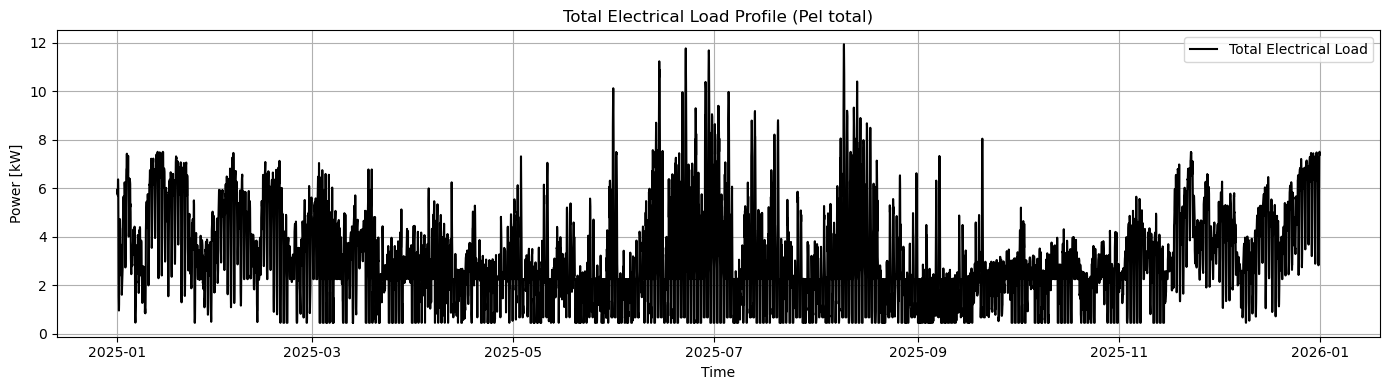

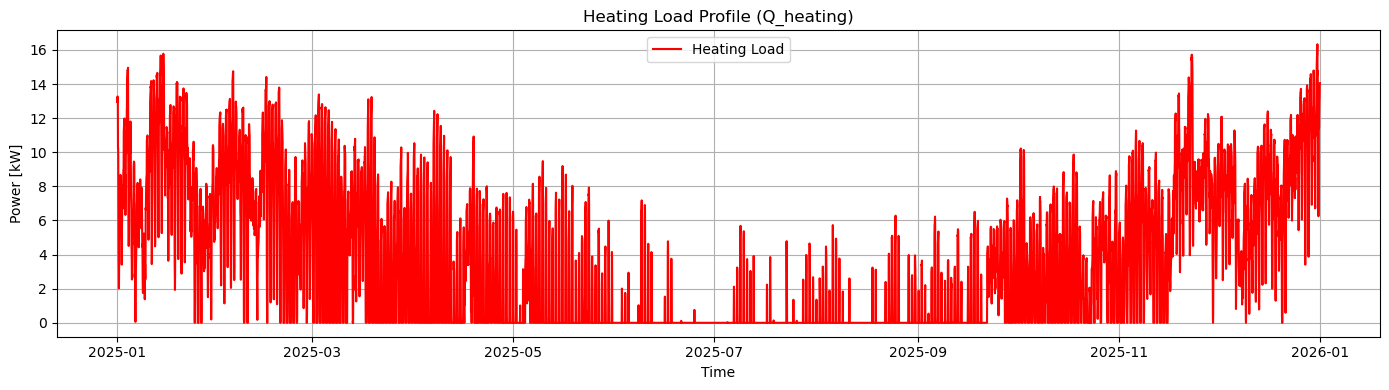

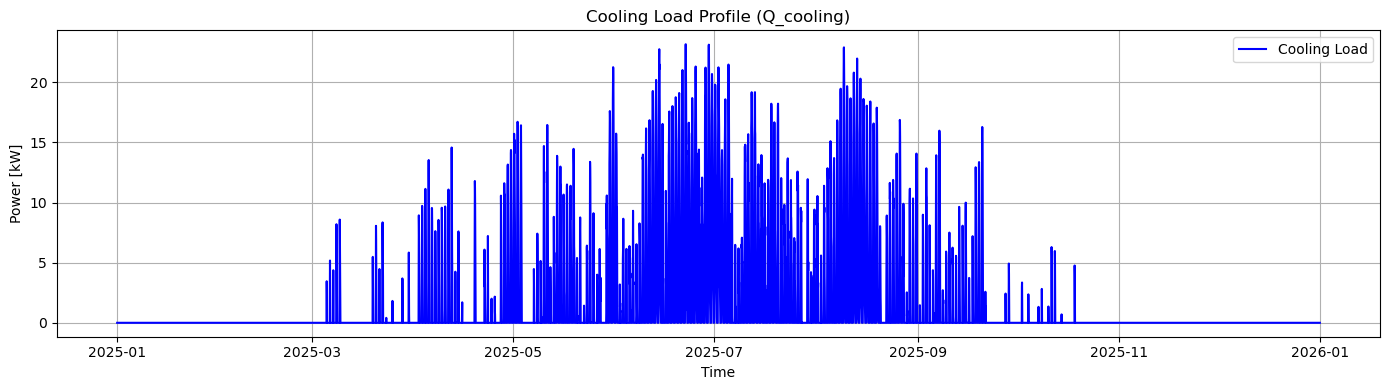

In [12]:
import matplotlib.pyplot as plt

# ====================================================
# 1) TOTAL ELECTRICAL LOAD PROFILE
# ====================================================
plt.figure(figsize=(14,4))

plt.plot(out.index,
         out["TotalElectric_kW"],
         label="Total Electrical Load",
         color="black")

plt.xlabel("Time")
plt.ylabel("Power [kW]")
plt.title("Total Electrical Load Profile (Pel total)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# ====================================================
# 2) HEATING LOAD PROFILE
# ====================================================
plt.figure(figsize=(14,4))

plt.plot(out.index,
         out["HeatingLoad_kW"],
         label="Heating Load",
         color="red")

plt.xlabel("Time")
plt.ylabel("Power [kW]")
plt.title("Heating Load Profile (Q_heating)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# ====================================================
# 3) COOLING LOAD PROFILE
# ====================================================
plt.figure(figsize=(14,4))

plt.plot(out.index,
         out["CoolingLoad_kW"],
         label="Cooling Load",
         color="blue")

plt.xlabel("Time")
plt.ylabel("Power [kW]")
plt.title("Cooling Load Profile (Q_cooling)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
# ====================================================
# EXPORT CSV FILES (INDIVIDUAL PROFILES)
# ====================================================

from pathlib import Path

# dossier de sauvegarde (même endroit que ton script / CSV météo)
EXPORT_DIR = Path(WEATHER_CSV).parent

# ----------------------------
# Heating load CSV
# ----------------------------
heating_csv = EXPORT_DIR / "Q_heating_profile.csv"

out[["HeatingLoad_kW"]].to_csv(
    heating_csv,
    index_label="timestamp"
)

print("✅ Heating CSV saved:", heating_csv)


# ----------------------------
# Cooling load CSV
# ----------------------------
cooling_csv = EXPORT_DIR / "Q_cooling_profile.csv"

out[["CoolingLoad_kW"]].to_csv(
    cooling_csv,
    index_label="timestamp"
)

print("✅ Cooling CSV saved:", cooling_csv)


# ----------------------------
# Total electrical load CSV
# ----------------------------
electric_csv = EXPORT_DIR / "Pel_total_profile.csv"

out[["TotalElectric_kW"]].to_csv(
    electric_csv,
    index_label="timestamp"
)

print("✅ Electric CSV saved:", electric_csv)

✅ Heating CSV saved: C:\Users\User\Downloads\Q_heating_profile.csv
✅ Cooling CSV saved: C:\Users\User\Downloads\Q_cooling_profile.csv
✅ Electric CSV saved: C:\Users\User\Downloads\Pel_total_profile.csv
